# 01 · EDA y Calidad de Datos
**TUMIPAY — Prueba Técnica Data Science Engineer**  
**Fecha de corte:** 2026-04-30

Objetivo: entender la estructura del dataset, detectar todos los problemas de calidad, construir la variable objetivo y dejar los datos listos para modelado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 50)

DATA = '../data/'
clientes = pd.read_csv(DATA + 'clientes.csv')
creditos = pd.read_csv(DATA + 'creditos.csv')
pagos    = pd.read_csv(DATA + 'pagos.csv')
eventos  = pd.read_csv(DATA + 'eventos_app.csv')

for n, d in [('clientes',clientes),('creditos',creditos),('pagos',pagos),('eventos',eventos)]:
    print(f'{n:12s}: {d.shape[0]:>6,} filas  x  {d.shape[1]:>2} cols')

clientes    :  1,400 filas  x  16 cols
creditos    :  1,527 filas  x  13 cols
pagos       : 10,434 filas  x  11 cols
eventos     : 13,324 filas  x   8 cols


## 1. Estructura y granularidad

| Tabla | Granularidad | Clave |
|---|---|---|
| clientes | 1 fila por cliente | cliente_id |
| creditos | 1 fila por crédito (1 cliente → N créditos) | credito_id |
| pagos | 1 fila por cuota (1 crédito → N cuotas) | pago_id |
| eventos_app | 1 fila por evento digital | evento_id |

In [2]:
# Tipos de datos
for n, d in [('CLIENTES',clientes),('CREDITOS',creditos),('PAGOS',pagos)]:
    print(f'\n=== {n} ===')
    print(d.dtypes)
    print(d.head(2))


=== CLIENTES ===
cliente_id                      str
fecha_registro                  str
departamento                    str
ciudad                          str
edad                          int64
genero                          str
estrato                       int64
nivel_educativo                 str
ocupacion                       str
ingreso_mensual_estimado    float64
canal_adquisicion               str
score_externo               float64
tiene_producto_ahorro          bool
numero_dependientes           int64
dispositivo_principal           str
email_hash                      str
dtype: object
  cliente_id fecha_registro     departamento  ciudad  edad genero  estrato  \
0    CL00001     2024-03-25  Valle del Cauca    Cali    41      M        1   
1    CL00002     2025-09-27           Tolima  Ibagué    35      F        3   

     nivel_educativo    ocupacion  ingreso_mensual_estimado canal_adquisicion  \
0  Técnico/Tecnólogo  Comerciante                 1600000.0   Campaña digita

## 2. Auditoría completa de calidad de datos

In [3]:
def reporte_calidad(df, nombre):
    nulos = df.isnull().sum()
    pct   = (nulos / len(df) * 100).round(2)
    dup   = df.duplicated().sum()
    print(f'\n=== {nombre.upper()} ===')
    rep = pd.DataFrame({'nulos': nulos, 'pct': pct})
    rep = rep[rep['nulos'] > 0]
    print(rep if len(rep) else '  Sin nulos.')
    print(f'  Filas duplicadas exactas: {dup}')

for n, d in [('clientes',clientes),('creditos',creditos),('pagos',pagos),('eventos',eventos)]:
    reporte_calidad(d, n)


=== CLIENTES ===
                          nulos  pct
ingreso_mensual_estimado     70  5.0
score_externo                49  3.5
  Filas duplicadas exactas: 0

=== CREDITOS ===
                  nulos   pct
producto_credito      6  0.39
  Filas duplicadas exactas: 0

=== PAGOS ===
            nulos   pct
fecha_pago    483  4.63
medio_pago     83  0.80
  Filas duplicadas exactas: 0

=== EVENTOS ===
  Sin nulos.
  Filas duplicadas exactas: 0


In [4]:
# Duplicados por email_hash (clientes con misma identidad)
dup_email = clientes[clientes.duplicated('email_hash', keep=False)]
print(f'Clientes con email_hash duplicado: {len(dup_email)}')
print(dup_email[['cliente_id','email_hash','fecha_registro']].head(8))

# Duplicados en pagos: mismo crédito + misma cuota
dup_pagos = pagos[pagos.duplicated(['credito_id','numero_cuota'], keep=False)]
print(f'\nCuotas duplicadas en pagos: {len(dup_pagos)}')
print(dup_pagos[['pago_id','credito_id','numero_cuota','valor_pagado','estado_pago']].head(6))

Clientes con email_hash duplicado: 22
    cliente_id   email_hash fecha_registro
87     CL00088  hash_666605     2024-09-25
162    CL00163  hash_666605     2024-10-14
188    CL00189  hash_887600     2024-03-01
192    CL00193  hash_901555     2025-07-04
202    CL00203  hash_840174     2023-12-13
214    CL00215  hash_114260     2024-05-26
235    CL00236  hash_359405     2023-12-09
335    CL00336  hash_359405     2023-11-04

Cuotas duplicadas en pagos: 40
         pago_id credito_id  numero_cuota  valor_pagado estado_pago
56    PG00000057   CR000008             9       1098000      Pagado
247   PG00000248   CR000037             4       1188000      Pagado
835   PG00000836   CR000129            12        191000      Pagado
1363  PG00001364   CR000205             2        158000      Pagado
2731  PG00002732   CR000415             1        621000      Pagado
2916  PG00002917   CR000443             9        181000      Pagado


In [5]:
# Normalización de texto en ciudad
print('Ciudades con posibles errores tipográficos:')
problemas_ciudad = ['Bogot', 'Barranquila', 'Medellin ']
for c in clientes['ciudad'].unique():
    if any(p in str(c) for p in problemas_ciudad):
        print(f'  -> "{c}" ({(clientes["ciudad"]==c).sum()} registros)')

# Edades fuera de rango
print(f'\nEdades < 18: {(clientes["edad"] < 18).sum()}')
print(f'Edades > 80: {(clientes["edad"] > 80).sum()}')
print(clientes[clientes['edad']<18][['cliente_id','edad','ocupacion']])

# Relación cuota/ingreso
print(f'\nRCI > 1 (cuota > ingreso): {(creditos["relacion_cuota_ingreso"] > 1).sum()}')
print(f'RCI > 0.5:                  {(creditos["relacion_cuota_ingreso"] > 0.5).sum()}')

Ciudades con posibles errores tipográficos:
  -> "Bogotá" (423 registros)
  -> "Bogot" (1 registros)
  -> "Medellin " (3 registros)
  -> "Barranquila" (2 registros)

Edades < 18: 5
Edades > 80: 2
     cliente_id  edad   ocupacion
84      CL00085    17    Empleado
802     CL00803    17  Pensionado
816     CL00817    17    Empleado
1121    CL01122    17  Estudiante
1338    CL01339    17    Empleado

RCI > 1 (cuota > ingreso): 10
RCI > 0.5:                  52


In [6]:
# Anomalías en pagos
pagos['ratio_pago'] = pagos['valor_pagado'] / pagos['valor_cuota']
print(f'Pagos completos (95-105%): {((pagos.ratio_pago>=0.95)&(pagos.ratio_pago<=1.05)).sum()}')
print(f'Pagos parciales (< 95%):   {(pagos.ratio_pago < 0.95).sum()}')
print(f'Sobrepagos (> 105%):       {(pagos.ratio_pago > 1.05).sum()}')
print(f'Sin pago (= 0):            {(pagos.valor_pagado == 0).sum()}')
print(f'\nTasa mensual > 10%:  {(creditos.tasa_interes_mensual > 0.10).sum()} créditos')

Pagos completos (95-105%): 9471
Pagos parciales (< 95%):   679
Sobrepagos (> 105%):       284
Sin pago (= 0):            483

Tasa mensual > 10%:  2 créditos


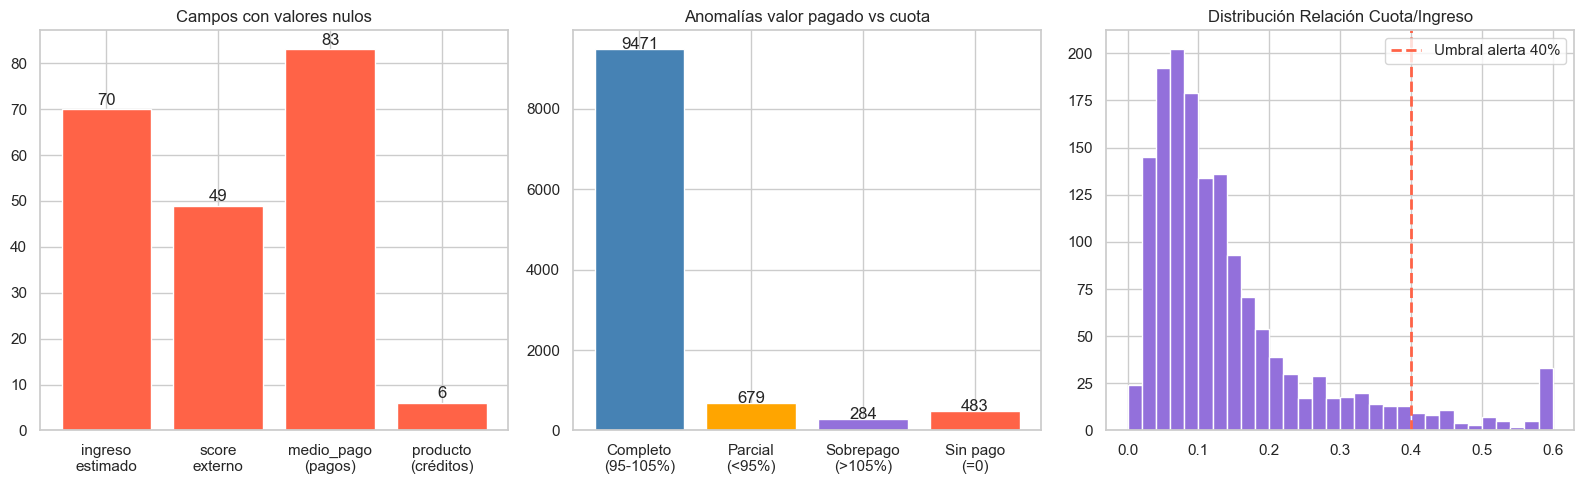

In [7]:
# Visualizar hallazgos de calidad
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

nulos = {'ingreso\nestimado': clientes['ingreso_mensual_estimado'].isna().sum(),
         'score\nexterno': clientes['score_externo'].isna().sum(),
         'medio_pago\n(pagos)': pagos['medio_pago'].isna().sum(),
         'producto\n(créditos)': creditos['producto_credito'].isna().sum()}
axes[0].bar(nulos.keys(), nulos.values(), color='tomato', edgecolor='white')
axes[0].set_title('Campos con valores nulos')
for i,(k,v) in enumerate(nulos.items()): axes[0].text(i, v+1, str(v), ha='center')

cats = {'Completo\n(95-105%)':((pagos.ratio_pago>=0.95)&(pagos.ratio_pago<=1.05)).sum(),
        'Parcial\n(<95%)':(pagos.ratio_pago<0.95).sum(),
        'Sobrepago\n(>105%)':(pagos.ratio_pago>1.05).sum(),
        'Sin pago\n(=0)':(pagos.valor_pagado==0).sum()}
axes[1].bar(cats.keys(), cats.values(), color=['steelblue','orange','mediumpurple','tomato'], edgecolor='white')
axes[1].set_title('Anomalías valor pagado vs cuota')
for i,(k,v) in enumerate(cats.items()): axes[1].text(i, v+5, str(v), ha='center')

axes[2].hist(creditos['relacion_cuota_ingreso'].clip(0,0.6), bins=30, color='mediumpurple', edgecolor='white')
axes[2].axvline(0.4, color='tomato', linestyle='--', lw=2, label='Umbral alerta 40%')
axes[2].set_title('Distribución Relación Cuota/Ingreso')
axes[2].legend()
plt.tight_layout()
plt.show()

## 3. Construcción de la variable objetivo `mora-30`

**Definición:** `mora-30 = 1` si el crédito tiene al menos una cuota dentro de las primeras 6 con `dias_mora > 30`.

**Justificaciones:**
- **30 días:** umbral regulatorio colombiano para mora C (Superfinanciera).
- **Primeras 6 cuotas:** usamos comportamiento temprano para evitar fuga de información. Variables calculadas sobre el historial completo no están disponibles al momento de la decisión de originación.
- **Mínimo 3 cuotas observadas:** garantizar señal suficiente para etiquetar.
- **Duplicados de cuota:** antes de calcular el target, eliminamos duplicados en pagos conservando el registro con mayor valor_pagado (el más representativo del comportamiento real).

In [8]:
pagos['fecha_vencimiento'] = pd.to_datetime(pagos['fecha_vencimiento'])
pagos['fecha_pago']        = pd.to_datetime(pagos['fecha_pago'])

# Limpiar duplicados primero
pagos_clean = pagos.sort_values('valor_pagado', ascending=False)\
                   .drop_duplicates(['credito_id','numero_cuota'], keep='first')
print(f'Pagos originales: {len(pagos)} | Tras dedup: {len(pagos_clean)}')

# Construir target sobre primeras 6 cuotas
mora_target = pagos_clean[pagos_clean['numero_cuota'] <= 6].groupby('credito_id').agg(
    max_dias_mora_6m   = ('dias_mora',    'max'),
    cuotas_observadas  = ('numero_cuota', 'count'),
    pct_pagadas_tiempo = ('estado_pago',  lambda x: (x=='Pagado').mean()),
    n_cuotas_con_mora  = ('dias_mora',    lambda x: (x > 0).sum()),
).reset_index()
mora_target = mora_target[mora_target['cuotas_observadas'] >= 3]
mora_target['mora_30'] = (mora_target['max_dias_mora_6m'] > 30).astype(int)

print(f'\nCréditos con target: {len(mora_target)}')
print(mora_target['mora_30'].value_counts())
print(f'Tasa de mora: {mora_target["mora_30"].mean():.2%}')

Pagos originales: 10434 | Tras dedup: 10414

Créditos con target: 1411
mora_30
0    1073
1     338
Name: count, dtype: int64
Tasa de mora: 23.95%


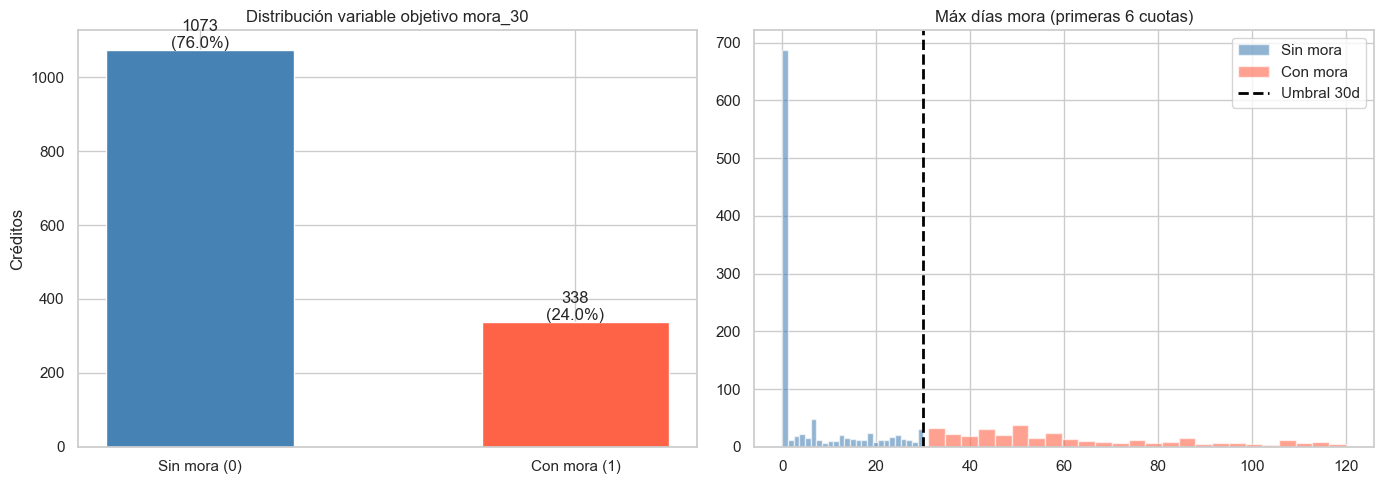

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mora_counts = mora_target['mora_30'].value_counts().rename({0:'Sin mora (0)', 1:'Con mora (1)'})
bars = axes[0].bar(mora_counts.index, mora_counts.values, color=['steelblue','tomato'], edgecolor='white', width=0.5)
axes[0].set_title('Distribución variable objetivo mora_30')
axes[0].set_ylabel('Créditos')
for bar, val in zip(bars, mora_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, f'{val}\n({val/len(mora_target):.1%})', ha='center')

axes[1].hist(mora_target[mora_target.mora_30==0]['max_dias_mora_6m'], bins=25, alpha=0.6, color='steelblue', label='Sin mora', edgecolor='white')
axes[1].hist(mora_target[mora_target.mora_30==1]['max_dias_mora_6m'], bins=25, alpha=0.6, color='tomato',    label='Con mora', edgecolor='white')
axes[1].axvline(30, color='black', linestyle='--', lw=2, label='Umbral 30d')
axes[1].set_title('Máx días mora (primeras 6 cuotas)')
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Decisiones de limpieza documentadas

| Problema detectado | Acción tomada | Justificación |
|---|---|---|
| `ingreso_mensual_estimado` 5% nulos | Imputar con mediana por `ocupacion` | Mejor estimador que mediana global |
| `score_externo` 3.5% nulos | Mediana global + flag `score_externo_nulo` | El hecho de no tener score puede ser señal de riesgo |
| `producto_credito` 6 nulos | Categoría 'Desconocido' | Volumen bajo, no impacta modelo |
| Email_hash duplicado | Reportado, sin eliminación | Podría ser familia o error operativo, requiere validación de negocio |
| Cuotas duplicadas en pagos | Conservar el registro con mayor valor_pagado | Más representativo del comportamiento real |
| Edad < 18 años | Flag `edad_sospechosa`, se conserva | Posible error de captura, pero no invalida el crédito |
| `relacion_cuota_ingreso` negativa | Imputar con mediana | Error de datos claro |
| Tasa mensual > 10% | Flag `tasa_outlier`, se conserva | Puede ser señal de riesgo legítima |
| Ciudad con errores tipográficos | Normalización de texto | Evita segmentación incorrecta |
| Créditos con < 3 cuotas observadas | Excluidos del target | Información insuficiente para etiquetar |